In [9]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2
!pip install scikeras scikit-learn==1.5.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [1]:
import sklearn
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)

TensorFlow: 2.20.0
Scikit-learn: 1.5.2


Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


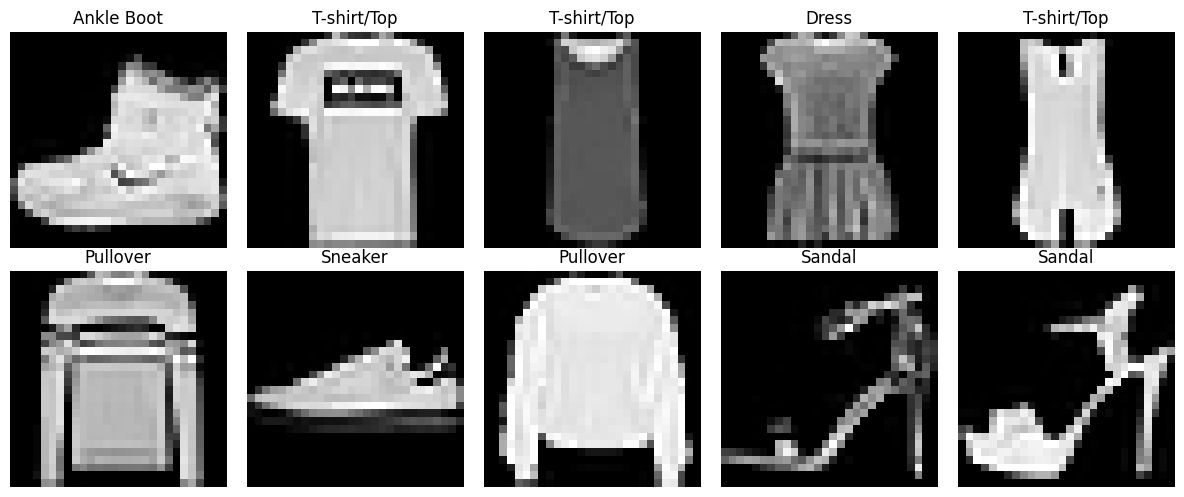

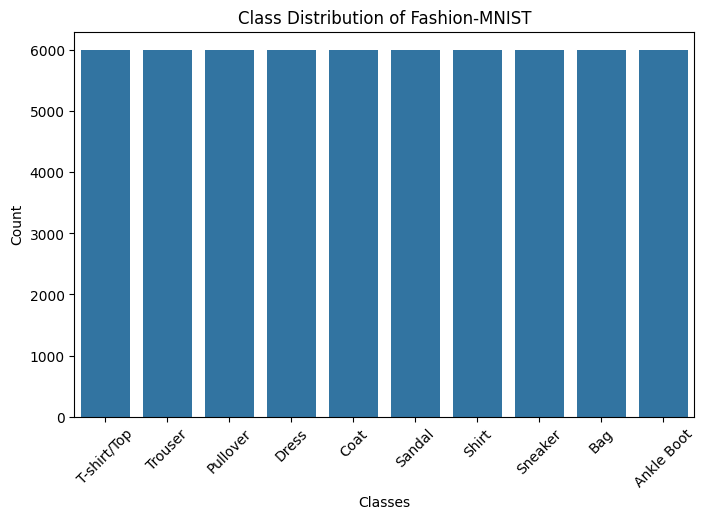

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist

# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Print dataset dimensions
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Display 10 sample images
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray', interpolation='nearest')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()

# Save image
plt.savefig("Task1_Sample_Images.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# Plot class distribution
plt.figure(figsize=(8,5))
sns.countplot(x=y_train)

plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution of Fashion-MNIST")

# Save image
plt.savefig("Task1_Class_Distribution.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [3]:
from tensorflow.keras.utils import to_categorical

# Print tensor shapes before preprocessing
print("Before Preprocessing")
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

# Flatten images
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)

# Normalize pixel values
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Print tensor shapes after preprocessing
print("\nAfter Preprocessing")
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train_cat.shape)
print("Testing Labels:", y_test_cat.shape)

Before Preprocessing
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)

After Preprocessing
Training Images: (60000, 784)
Testing Images: (10000, 784)
Training Labels: (60000, 10)
Testing Labels: (10000, 10)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the MLP model
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8190 - loss: 0.5080 - val_accuracy: 0.8403 - val_loss: 0.4373
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8624 - loss: 0.3769 - val_accuracy: 0.8562 - val_loss: 0.3881
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8754 - loss: 0.3392 - val_accuracy: 0.8739 - val_loss: 0.3471
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8826 - loss: 0.3176 - val_accuracy: 0.8784 - val_loss: 0.3334
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8899 - loss: 0.2978 - val_accuracy: 0.8707 - val_loss: 0.3544
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8937 - loss: 0.2838 - val_accuracy: 0.8786 - val_loss: 0.3461
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8977 - loss: 0.2697 - val_accuracy: 0.8841 - val_loss: 0.3190
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9008 - loss: 0.2613

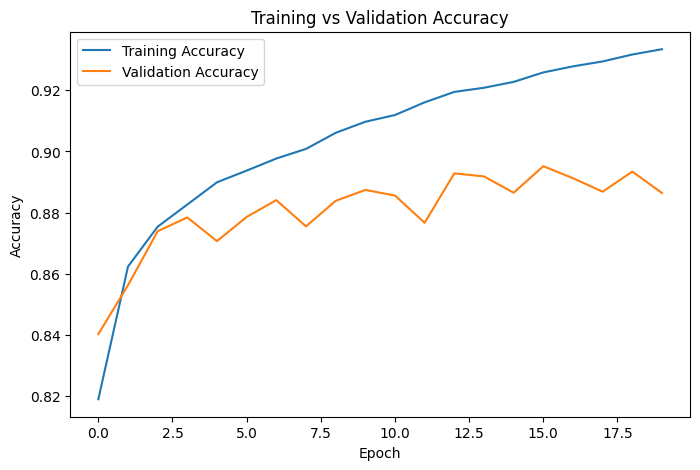

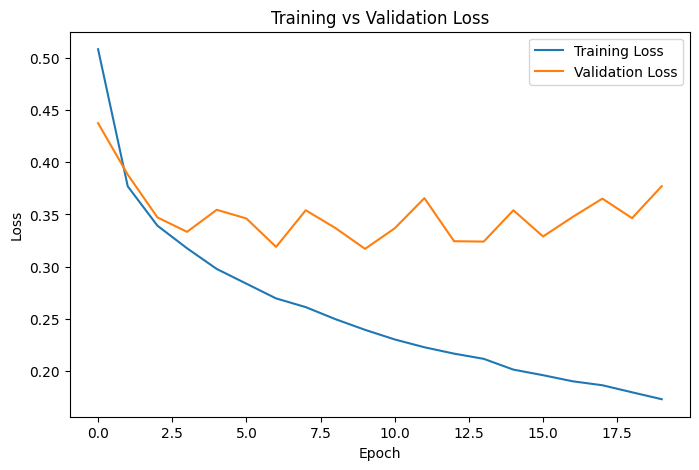

In [5]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Save image
plt.savefig("Task4_Training_Validation_Accuracy.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# Plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Save image
plt.savefig("Task4_Training_Validation_Loss.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy : 0.8792
Precision: 0.8814394081354527
Recall   : 0.8792
F1 Score : 0.8782962420493976


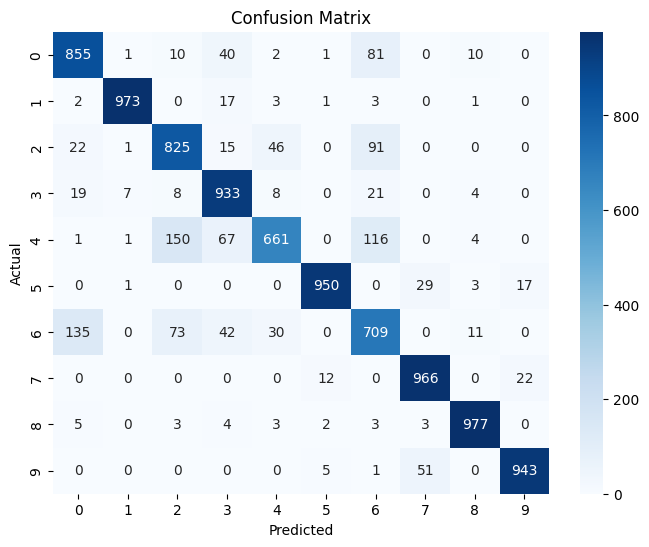

              precision    recall  f1-score   support

 T-shirt/Top       0.82      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.77      0.82      0.80      1000
       Dress       0.83      0.93      0.88      1000
        Coat       0.88      0.66      0.75      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.69      0.71      0.70      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.97      0.98      0.97      1000
  Ankle Boot       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [6]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Predict test data
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

baseline_accuracy = accuracy
baseline_precision = precision
baseline_recall = recall
baseline_f1 = f1

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save image
plt.savefig("Task5_Confusion_Matrix.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))
# Save baseline metrics
baseline_accuracy = accuracy
baseline_precision = precision
baseline_recall = recall
baseline_f1 = f1

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# One-hot encode labels
y_train_cat = to_categorical(y_train)

# Model function
def build_model(hidden_layers=2,
                neurons=128,
                learning_rate=0.001,
                optimizer="adam",
                activation="relu",
                dropout_rate=0.0):

    model = Sequential()

    model.add(Input(shape=(784,)))

    model.add(Dense(neurons, activation=activation))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


classifier = KerasClassifier(
    model=build_model,
    verbose=0
)

# Smaller search space
param_dist = {
    "model__hidden_layers": [1, 2],
    "model__neurons": [64],
    "model__learning_rate": [0.001],
    "model__optimizer": ["adam"],
    "model__activation": ["relu"],
    "model__dropout_rate": [0.0],
    "epochs": [5],
    "batch_size": [64]
}

search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_dist,
    n_iter=2,
    cv=2,
    verbose=2,
    random_state=42,
    scoring="accuracy"
)

search.fit(X_train, y_train_cat)

print("Best Score:", search.best_score_)
print("Best Parameters:")
print(search.best_params_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=   9.5s
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=   9.8s
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=   9.1s
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=   9.4s


/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Score: 0.8671166666666666
Best Parameters:
{'model__optimizer': 'adam', 'model__neurons': 64, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'relu', 'epochs': 5, 'batch_size': 64}


In [8]:
from tensorflow.keras.utils import to_categorical

# One-hot encode test labels if not already done
y_test_cat = to_categorical(y_test)

best_params = search.best_params_

optimized_model = build_model(
    hidden_layers=best_params["model__hidden_layers"],
    neurons=best_params["model__neurons"],
    learning_rate=best_params["model__learning_rate"],
    optimizer=best_params["model__optimizer"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"]
)

history = optimized_model.fit(
    X_train,
    y_train_cat,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8047 - loss: 0.5550 - val_accuracy: 0.8458 - val_loss: 0.4394
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8579 - loss: 0.3971 - val_accuracy: 0.8445 - val_loss: 0.4030
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8705 - loss: 0.3575 - val_accuracy: 0.8690 - val_loss: 0.3610
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8799 - loss: 0.3316 - val_accuracy: 0.8735 - val_loss: 0.3597
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8865 - loss: 0.3143 - val_accuracy: 0.8770 - val_loss: 0.3486


In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import numpy as np

loss, accuracy = optimized_model.evaluate(X_test, y_test_cat, verbose=0)

y_pred = np.argmax(optimized_model.predict(X_test), axis=1)

print("Test Accuracy :", accuracy)
print("Precision :", precision_score(y_test, y_pred, average="weighted"))
print("Recall :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy : 0.8701000213623047
Precision : 0.8717745048528215
Recall : 0.8701
F1 Score : 0.8659834943123684

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.89      0.83      1000
           1       1.00      0.96      0.98      1000
           2       0.78      0.78      0.78      1000
           3       0.84      0.91      0.87      1000
           4       0.74      0.84      0.79      1000
           5       0.96      0.95      0.96      1000
           6       0.81      0.49      0.61      1000
           7       0.93      0.94      0.94      1000
           8       0.94      0.97      0.96      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Confusion Matrix

[[893   0  11  37   6   1  39   1  12   0]
 [

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline", "Optimized"],
    "Accuracy": [
        baseline_accuracy,
        accuracy
    ],
    "Precision": [
        baseline_precision,
        precision_score(y_test, y_pred, average="weighted")
    ],
    "Recall": [
        baseline_recall,
        recall_score(y_test, y_pred, average="weighted")
    ],
    "F1 Score": [
        baseline_f1,
        f1_score(y_test, y_pred, average="weighted")
    ]
})

print(comparison)

       Model  Accuracy  Precision  Recall  F1 Score
0   Baseline    0.8792   0.881439  0.8792  0.878296
1  Optimized    0.8701   0.871775  0.8701  0.865983


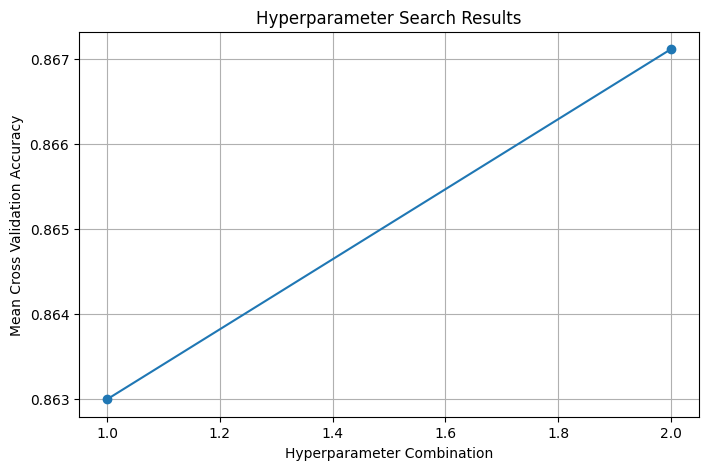

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(results)+1),
    results["mean_test_score"],
    marker="o"
)

plt.xlabel("Hyperparameter Combination")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")

plt.grid(True)

plt.savefig(
    "Task8_Hyperparameter_Search_Results.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

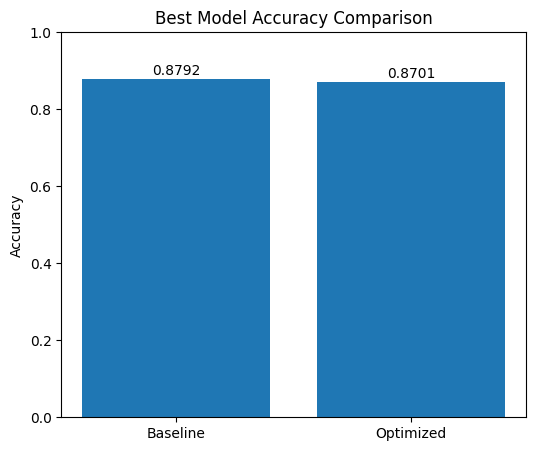

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

models = ["Baseline", "Optimized"]
accuracies = [baseline_accuracy, accuracy]

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")
plt.ylim(0,1)

for i,v in enumerate(accuracies):
    plt.text(i,v+0.01,f"{v:.4f}",ha="center")

plt.savefig(
    "Task9_Best_Model_Accuracy_Comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()